In [1]:
import os
# print(os.getcwd())
cwd = os.chdir(f"{os.getcwd()}/../") 
# print(os.getcwd())

In [2]:
import pandas as pd
import pytz
from datetime import datetime as dtt

In [3]:
from src.constants import PROJECT_ROOT
from src.data.preprocessing import compute_returns, scale_data
from src.backtest.models.pca import fit_pca
from src.backtest.strategies import pca_strategy
from src.backtest.portfolio import generate_portfolio, convert_multi_to_single_asset
from src.backtest.backtester import compute_all_metrics
from src.backtest.plot import plot_portfolio_val

In [4]:
pd.set_option('display.max_columns', None)

### Define Strategy - PCA

In [5]:
strategy = 'PCA'

### Get Close Prices Data

#### !! Dataset will be expanded in the near future to include 3-5 years and 30 stocks.

In [6]:
prices_df = pd.read_csv(f'{PROJECT_ROOT}/src/data/hist/commods/commods_prices.csv')
print('Close Prices:')
display(prices_df)

Close Prices:


,date,wheat,corn,oil,gas,coal
0,2026-01-01,100,50,70,30,10
1,2026-01-02,102,51,69,31,11
2,2026-01-03,101,52,71,30,12
3,2026-01-04,103,51,72,32,11
4,2026-01-05,104,53,73,33,13


## Perform Data Preprocessing

### Compute Returns

In [7]:
cols = ['wheat', 'corn', 'oil', 'gas', 'coal']
returns_df = compute_returns(prices_df, cols)
returns_df = returns_df.set_index('date')
print('Returns:')
display(returns_df)

         date     wheat      corn       oil       gas      coal
1  2026-01-02  0.020000  0.020000 -0.014286  0.033333  0.100000
2  2026-01-03 -0.009804  0.019608  0.028986 -0.032258  0.090909
3  2026-01-04  0.019802 -0.019231  0.014085  0.066667 -0.083333
4  2026-01-05  0.009709  0.039216  0.013889  0.031250  0.181818
Returns:


,wheat,corn,oil,gas,coal
date,,,,,
2026-01-02,0.020000,0.020000,-0.014286,0.033333,0.100000
2026-01-03,-0.009804,0.019608,0.028986,-0.032258,0.090909
2026-01-04,0.019802,-0.019231,0.014085,0.066667,-0.083333
2026-01-05,0.009709,0.039216,0.013889,0.031250,0.181818


### Scale Data

In [8]:
pca_df = returns_df.copy()
pca_df = pca_df[cols]
scaled_X, scaler = scale_data(pca_df)

[[ 0.83059354  0.24021249 -1.59403734  0.23990105  0.2862349 ]
 [-1.62688738  0.22174827  1.17008509 -1.59292422  0.19213027]
 [ 0.81426583 -1.60692038  0.21822407  1.17133685 -1.61154167]
 [-0.01797199  1.14495962  0.20572818  0.18168632  1.1331765 ]]


### Fit PCA

In [9]:
pca, principal_components, residuals = fit_pca(scaled_X, n_components=2)

n_components:2
principal components:
[[ 0.80536674  1.525309  ]
 [-2.20666128 -1.2812458 ]
 [ 2.35046508 -1.29934536]
 [-0.94917054  1.05528217]]
PCA components:
[[ 0.51826031 -0.43200081 -0.29707249  0.52655798 -0.42339838]
 [ 0.33594541  0.49903187 -0.59039405  0.15902477  0.51405628]]
PCA n components:
2


## Run Backtest

### Run PCA Strategy & Generate Signals

In [10]:
print(f'Strategy: {strategy}\n')

signal_df, holding_df, weights_df, trade_df = pca_strategy(residuals, returns_df.index, cols)
# else:
#     y_col = 'Wheat'
#     x_cols = ['Corn','Oil','Gas','Coal']
#     r_square, y_pred = linear_regression(returns_df, y_col, x_cols)
#     returns_df = regression_signal(returns_df, y_pred)
print(f'\nsignal_df:\n{signal_df}')
print(f'\nholding_df:\n{holding_df}')
print(f'\nweights_df:\n{weights_df}')
print(f'\ntrade_df:\n{trade_df}')

Strategy: PCA

index:Index(['2026-01-02', '2026-01-03', '2026-01-04', '2026-01-05'], dtype='object', name='date')
cols:['wheat', 'corn', 'oil', 'gas', 'coal']
signal:[[-1.09983674 -0.60108264  1.29859456  1.11269363 -0.71036882]
 [-1.09983674 -0.60108264  1.29859456  1.11269363 -0.71036882]
 [ 1.09983674  0.60108264 -1.29859456 -1.11269363  0.71036882]
 [ 1.09983674  0.60108264 -1.29859456 -1.11269363  0.71036882]]

signal_df:
               wheat      corn       oil       gas      coal
date                                                        
2026-01-02 -1.099837 -0.601083  1.298595  1.112694 -0.710369
2026-01-03 -1.099837 -0.601083  1.298595  1.112694 -0.710369
2026-01-04  1.099837  0.601083 -1.298595 -1.112694  0.710369
2026-01-05  1.099837  0.601083 -1.298595 -1.112694  0.710369

holding_df:
            wheat  corn  oil  gas  coal
date                                   
2026-01-02      1     0   -1   -1     0
2026-01-03      1     0   -1   -1     0
2026-01-04     -1     0    1  

In [11]:
cols = pd.MultiIndex.from_product([["signal", "holding", "weights", "trade"], returns_df.columns])
df = pd.DataFrame(index=returns_df.index, columns=cols)
df['signal'] = signal_df
df['holding'] = holding_df
df['weights'] = weights_df
df['trade'] = trade_df

### Generate Portfolio

In [12]:
execution_params = {
        'initial_capital': 100000,
        'allocation': 0.5,
        'cost_per_shr': 0.005
    }

In [13]:
portfolio_df = convert_multi_to_single_asset(holding_df, trade_df, prices_df)
portfolio_df = generate_portfolio(portfolio_df, execution_params)

prices_df:         date  wheat  corn  oil  gas  coal
0  2026-01-01    100    50   70   30    10
1  2026-01-02    102    51   69   31    11
2  2026-01-03    101    52   71   30    12
3  2026-01-04    103    51   72   32    11
4  2026-01-05    104    53   73   33    13
Calculating Positions and Trades...
Calculating Returns...
Calculating Pnl...


### Run Metrics

In [14]:
# def metrics(returns_df):
#     """
#     Sharpe ratio measures risk adjusted returns
#     :param returns_df:
#     :return:
#     """    
#     returns_df['cum_ret'] = (1 + returns_df['daily_ret']).cumprod()
#     print(returns_df)

#     if returns_df['daily_ret'].std() == 0:
#         sharpe_ratio = 0
#     else:
#         sharpe_ratio = round(returns_df['daily_ret'].mean() / returns_df['daily_ret'].std() * np.sqrt(252), 2)
#     max_dd = (returns_df['cum_ret'] / returns_df['cum_ret'].cummax() - 1).min()
#     total_cum_ret = returns_df['cum_ret'].iloc[-1] - 1
#     print(f'\nsharpe ratio: {sharpe_ratio}')
#     print(f'\nmax drawdown: {max_dd:.2%}')
#     print(f'\nTotal cumulative return: {total_cum_ret:.2%}')
#     metrics_df = pd.DataFrame({
#         'Sharpe Ratio': [sharpe_ratio],
#         'Max Drawdown': [max_dd],
#         'Total Cumulative Return': [total_cum_ret],
#     })
#     print(f'\nmetrics_df:\n{metrics_df}')
#     return metrics_df

In [15]:
date_str = dtt.now(pytz.timezone('America/New_York')).strftime('%Y_%m_%d')
strategy_id = f'pca_{date_str}'

metrics_df = compute_all_metrics(portfolio_df, strategy_id, execution_params['initial_capital'])


entries: 0, exits: 0
trade_pnl: 
   trade_id  daily_pnl
0         0        0.0
Profitable Trades: 0
Non-Profitable Trades: 0
Total Trades: 1
% of profitable trades: 0.0
Average PnL per Trade: $0.0

trades_metrics_df:
      strategy_id  entries  exits  profitable_trades  non_profitable_trades  \
0  pca_2026_04_16        0      0                  0                      0   

   total_trades  pct_profitable  avg_pnl_per_trade  
0             1             0.0                0.0  
      strategy_id  entries  exits  profitable_trades  non_profitable_trades  \
0  pca_2026_04_16        0      0                  0                      0   

   total_trades  pct_profitable  avg_pnl_per_trade  
0             1             0.0                0.0  

recent_trades_df:
      strategy_id        date  entry   exit  position  position_shrs  trade  \
0  pca_2026_04_16  2026-01-02  False  False  -50000.0            0.0      0   
1  pca_2026_04_16  2026-01-03  False  False  -50000.0            0.0      0 

### Plot Portfolio Value

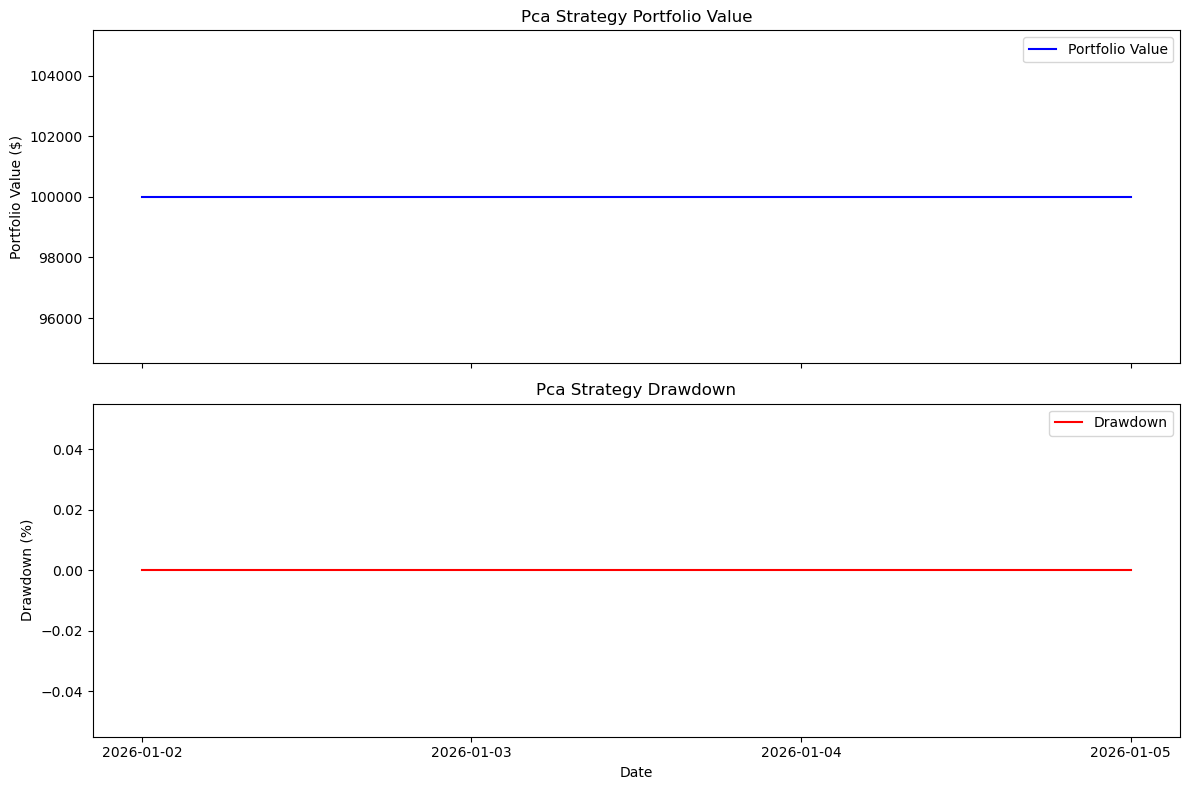

In [16]:
plot_portfolio_val(portfolio_df, strategy_type=strategy)

In [17]:
pd.reset_option('display.max_columns')